# Smoke test 07: analytic JADES-like spectrum plumbing

This notebook was moved out of `notebooks/validation` because it uses an analytic stellar continuum and/or toy nebular lines. It is useful for fast plumbing checks, not real scientific validation.

# JADES-like NIRSpec PRISM simulation at z=10

This notebook stress-tests the spectrum-fitting machinery on a more realistic high-redshift case: a simulated JWST/NIRSpec PRISM/CLEAR spectrum for a galaxy at `z = 10`.

Instrument assumptions used here:

- NIRSpec PRISM/CLEAR wavelength range: **0.60-5.30 micron**.
- Low-resolution PRISM resolving power is wavelength dependent, roughly **R ~ 30-300** in the STScI user documentation and **R = 30-330** in Jakobsen et al. (2022).
- NIRSpec resolving-power curves are tabulated by STScI in `jwst_nirspec_prism_disp.fits`; this notebook uses a smooth approximation to that curve unless a local copy is supplied.
- Resolution elements are sampled by about **2.2 pixels**, following the STScI definition of the resolving-power curves.

Sources to audit:

- STScI NIRSpec dispersers/filters page: PRISM/CLEAR is listed as `~100`, `0.60-5.30 micron`; the same page notes low-resolution mode `R ~ 30-300` and provides the prism dispersion/resolution FITS table.
- Jakobsen et al. 2022 NIRSpec overview: prism spectroscopy over `0.6-5.3 micron` with `R=30-330`.

Scientific goal: check whether the current likelihood machinery can recover redshift and broad continuum/line parameters from a high-z PRISM-like spectrum with a Lyman break and rest-UV/optical emission lines. This is still a simulated same-model recovery, not a claim of physical realism.

In [1]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

from sedinfer.experimental.jaxcigale import (
    GaussianSpectralData,
    JaxFilterSet,
    JaxParameterSpace,
    UniformJaxPrior,
    analytic_stellar_module,
    build_jax_sed_model,
    calzetti_attenuation_module,
    madau_igm_module,
    model_spectrum_on_observed_pixels,
    nebular_emulator_module,
    pixel_edges_from_centers_numpy,
    redshift_module,
    run_numpyro_nuts,
)

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True})

def find_repo_root(start):
    path = Path(start).resolve()
    for candidate in (path, *path.parents):
        if (candidate / "sedinfer").is_dir() and (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate sedinfer repository root.")

REPO_ROOT = find_repo_root(Path.cwd())
OUTPUT_DIR = REPO_ROOT / "notebooks" / "outputs" / "jades_like_nirspec_prism_z10"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIT_FILE = OUTPUT_DIR / "nuts_jades_like_prism_fit.npz"
SUMMARY_FILE = OUTPUT_DIR / "nuts_jades_like_prism_fit_summary.json"

RUN_NUTS = not FIT_FILE.exists()
print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())
print("Output directory:", OUTPUT_DIR)
print("Run NUTS in this execution:", RUN_NUTS)

JAX backend: cpu
JAX devices: [CpuDevice(id=0)]
Output directory: /Users/gregoire/Documents/Sedfitting/sedinfer-public/notebooks/outputs/jades_like_nirspec_prism_z10
Run NUTS in this execution: True


## NIRSpec PRISM/CLEAR wavelength grid and resolving power

The function below constructs a PRISM-like pixel grid. It is not a JWST pipeline wavelength solution. It is a compact stand-in that preserves the important features for likelihood testing:

- observed wavelength span is 0.6-5.3 micron;
- resolving power increases strongly with wavelength;
- spectral pixels oversample resolution elements by 2.2 pixels.

For production validation, replace `approximate_nirspec_prism_resolving_power` with the STScI tabulated `jwst_nirspec_prism_disp.fits` curve.

PRISM-like pixels: 712
Observed wavelength range: 0.60-5.30 micron
Resolving-power range on pixels: 30.0-330.0


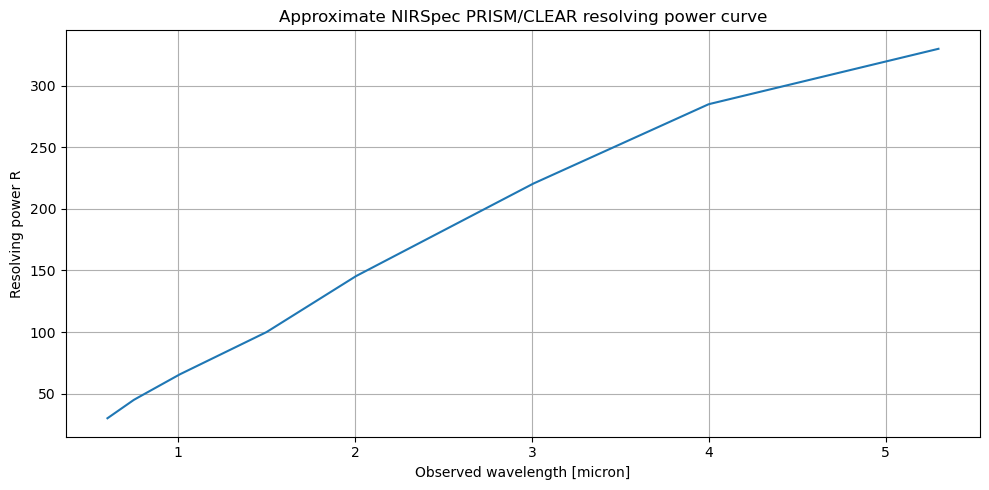

In [2]:
def approximate_nirspec_prism_resolving_power(wave_um):
    """Smooth approximation to NIRSpec PRISM/CLEAR R(lambda).

    Anchor values follow the public instrument description rather than the ETC.
    The shape is monotonic and spans R~30 at the blue end to R~330 at 5.3 um.
    """

    wave_um = np.asarray(wave_um, dtype=float)
    anchor_wave = np.array([0.60, 0.75, 1.00, 1.50, 2.00, 3.00, 4.00, 5.30])
    anchor_r = np.array([30.0, 45.0, 65.0, 100.0, 145.0, 220.0, 285.0, 330.0])
    return np.interp(wave_um, anchor_wave, anchor_r)

def make_prism_pixel_grid(wave_min_um=0.60, wave_max_um=5.30, pixels_per_resolution_element=2.2):
    centers = [float(wave_min_um)]
    while centers[-1] < wave_max_um:
        r_here = float(approximate_nirspec_prism_resolving_power(centers[-1]))
        delta_um = centers[-1] / (pixels_per_resolution_element * r_here)
        centers.append(centers[-1] + delta_um)
    centers = np.asarray(centers)
    centers = centers[centers <= wave_max_um]
    return centers * 1.0e4  # micron -> Angstrom

spectral_wave_a = make_prism_pixel_grid()
spectral_edges_a = pixel_edges_from_centers_numpy(spectral_wave_a)
resolving_power = approximate_nirspec_prism_resolving_power(spectral_wave_a / 1.0e4)

print(f"PRISM-like pixels: {spectral_wave_a.size}")
print(f"Observed wavelength range: {spectral_wave_a[0]/1e4:.2f}-{spectral_wave_a[-1]/1e4:.2f} micron")
print(f"Resolving-power range on pixels: {resolving_power.min():.1f}-{resolving_power.max():.1f}")

fig, ax = plt.subplots()
ax.plot(spectral_wave_a / 1.0e4, resolving_power)
ax.set_xlabel("Observed wavelength [micron]")
ax.set_ylabel("Resolving power R")
ax.set_title("Approximate NIRSpec PRISM/CLEAR resolving power curve")
fig.tight_layout()

## Build a high-z spectral model

This deliberately uses a simple analytic stellar continuum plus a toy nebular-line module. The point of this notebook is the spectroscopic machinery, not a final high-z stellar population model.

The lines are placed at common rest-frame wavelengths so that at `z=10` the PRISM spectrum contains a visible Lyman break and several rest-UV/optical lines. `Hbeta` and `[OIII]` are mostly redward of 5.3 micron at z=10, which is exactly the kind of high-z coverage edge we want to test.

In [3]:
def toy_highz_nebular_lines(wave_rest_a, line_scale=1.0, logzsol=-0.5):
    """Toy rest-frame nebular spectrum in Lsun/Angstrom per solar mass.

    This is only a validation source. It creates CIII], [OII], Hdelta, Hgamma,
    and a mostly IGM-suppressed Ly-alpha line.
    """

    wave = jnp.asarray(wave_rest_a)
    metallicity_factor = 10.0 ** (0.15 * logzsol)
    scale = line_scale * metallicity_factor

    continuum = 3.0e-9 * scale * (wave / 3000.0) ** -0.3

    def gaussian(center_a, sigma_a, equivalent_width_a):
        local_continuum = 2.0e-7 * (center_a / 5500.0) ** -1.4
        amplitude = local_continuum * equivalent_width_a / (jnp.sqrt(2.0 * jnp.pi) * sigma_a)
        return amplitude * jnp.exp(-0.5 * ((wave - center_a) / sigma_a) ** 2)

    lines = scale * (
        gaussian(1215.67, 1.2, 80.0)
        + gaussian(1908.7, 1.5, 25.0)
        + gaussian(3727.0, 2.0, 70.0)
        + gaussian(4102.0, 2.0, 18.0)
        + gaussian(4341.0, 2.0, 25.0)
        + gaussian(4861.0, 2.5, 35.0)
        + gaussian(5007.0, 2.5, 120.0)
    )
    return continuum, lines

wave_rest_a = np.linspace(500.0, 5600.0, 900)
dummy_filter_wave = np.linspace(7000.0, 52000.0, 64)
filters = JaxFilterSet.from_curves(["dummy"], [dummy_filter_wave], [np.ones_like(dummy_filter_wave)])

parameter_names = ["log10_mass", "z", "logzsol", "dust2", "line_scale"]
parameter_space = JaxParameterSpace(
    names=parameter_names,
    priors={
        "log10_mass": UniformJaxPrior(8.0, 10.6),
        "z": UniformJaxPrior(8.5, 11.5),
        "logzsol": UniformJaxPrior(-1.5, 0.2),
        "dust2": UniformJaxPrior(0.0, 0.5),
        "line_scale": UniformJaxPrior(0.1, 3.0),
    },
)

model = build_jax_sed_model(
    modules=[
        analytic_stellar_module(),
        nebular_emulator_module(toy_highz_nebular_lines, parameter_names=("line_scale", "logzsol")),
        calzetti_attenuation_module(av_parameter="dust2", slope_parameter=None, bump_amplitude_parameter=None),
        madau_igm_module(),
        redshift_module(),
    ],
    wavelength_grid_a=wave_rest_a,
    filters=filters,
    parameter_space=parameter_space,
)

true_theta = np.array([9.15, 10.0, -0.65, 0.08, 1.25])
initial_theta = np.array([9.0, 9.8, -0.5, 0.05, 1.0])

pd.DataFrame({"parameter": parameter_names, "truth": true_theta, "initial": initial_theta})

,parameter,truth,initial
0,log10_mass,9.15,9.00
1,z,10.00,9.80
2,logzsol,-0.65,-0.50
3,dust2,0.08,0.05
4,line_scale,1.25,1.00


## Simulate the PRISM observation

The model is evaluated at high resolution, redshifted to observed frame, broadened with the wavelength-dependent PRISM LSF, and binned into PRISM-like pixels. Noise is deliberately simple: a fractional component plus a floor. A few wavelength regions are masked to mimic bad reduction regions.

In [4]:
rng = np.random.default_rng(2026)
state_true = model.run_modules_mass_scaled(jnp.asarray(true_theta))
true_flux_pixel = np.asarray(
    model_spectrum_on_observed_pixels(
        state_true.wave_obs_a,
        state_true.flux_lambda_cgs,
        jnp.asarray(spectral_wave_a),
        jnp.asarray(spectral_edges_a),
        resample_mode="bin",
        resolving_power=resolving_power,
    )
)

# Very rough JADES-like high-z spectrum noise: continuum is low S/N blueward of the break,
# moderate S/N in the red continuum, and finite noise floor everywhere.
red_continuum = np.nanmedian(true_flux_pixel[(spectral_wave_a > 16000.0) & (spectral_wave_a < 35000.0)])
noise_floor = 0.05 * red_continuum
sigma_flux = 0.10 * np.abs(true_flux_pixel) + noise_floor
observed_flux = true_flux_pixel + rng.normal(0.0, sigma_flux)

mask = np.ones_like(spectral_wave_a, dtype=bool)
# Noisy blue edge and a few generic reduction/telluric-like windows.
for lo_um, hi_um in [(0.60, 0.68), (2.85, 2.95), (4.95, 5.05)]:
    mask &= ~((spectral_wave_a / 1e4 >= lo_um) & (spectral_wave_a / 1e4 <= hi_um))

spectral_data = GaussianSpectralData(
    wavelength_obs_a=spectral_wave_a,
    flux_lambda_cgs=observed_flux,
    sigma_lambda_cgs=sigma_flux,
    mask=mask,
    pixel_edges_obs_a=spectral_edges_a,
    resolving_power=resolving_power,
    resample_mode="bin",
)

lya_obs_um = 1215.67 * (1.0 + true_theta[1]) / 1.0e4
oii_obs_um = 3727.0 * (1.0 + true_theta[1]) / 1.0e4
hgamma_obs_um = 4341.0 * (1.0 + true_theta[1]) / 1.0e4
print(f"Ly-alpha observed wavelength: {lya_obs_um:.3f} micron")
print(f"[OII] observed wavelength: {oii_obs_um:.3f} micron")
print(f"Hgamma observed wavelength: {hgamma_obs_um:.3f} micron")
print(f"Active pixels: {mask.sum()} / {mask.size}")

Ly-alpha observed wavelength: 1.337 micron
[OII] observed wavelength: 4.100 micron
Hgamma observed wavelength: 4.775 micron
Active pixels: 672 / 712


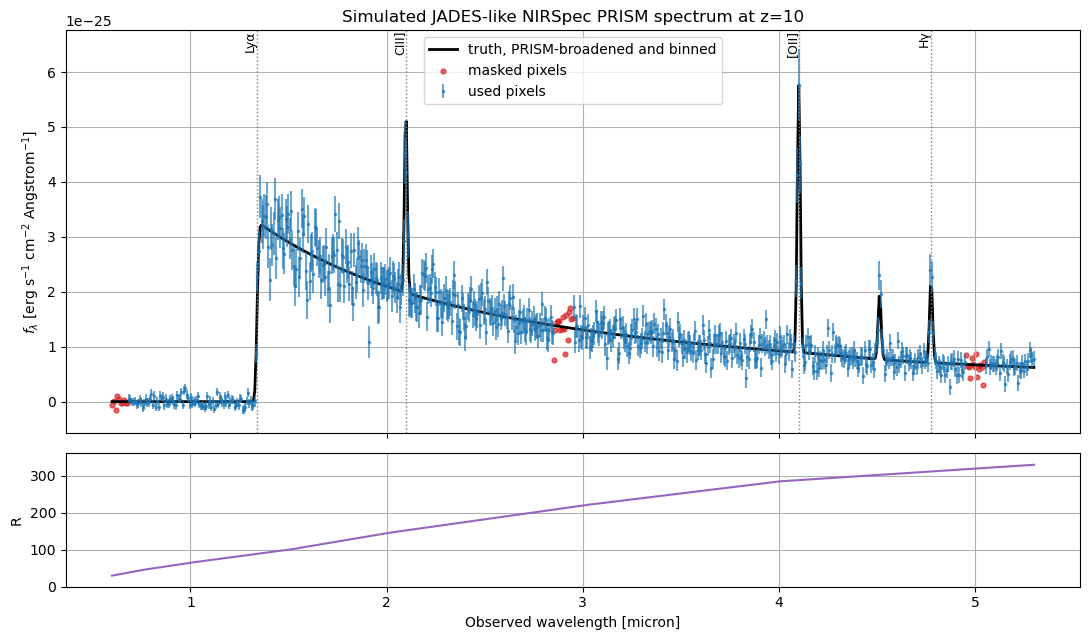

In [5]:
fig, (ax, rx) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
wave_um = spectral_wave_a / 1.0e4
ax.plot(wave_um, true_flux_pixel, color="black", lw=2, label="truth, PRISM-broadened and binned")
ax.errorbar(wave_um[mask], observed_flux[mask], yerr=sigma_flux[mask], fmt=".", ms=3, alpha=0.65, label="used pixels")
ax.scatter(wave_um[~mask], observed_flux[~mask], s=12, color="tab:red", alpha=0.7, label="masked pixels")
for label, x in [("Lyα", lya_obs_um), ("CIII]", 1908.7 * 11.0 / 1e4), ("[OII]", oii_obs_um), ("Hγ", hgamma_obs_um)]:
    ax.axvline(x, color="0.5", ls=":", lw=1)
    ax.text(x, ax.get_ylim()[1], label, rotation=90, va="top", ha="right", fontsize=9)
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Angstrom$^{-1}$]")
ax.set_title("Simulated JADES-like NIRSpec PRISM spectrum at z=10")
ax.legend(loc="best")

rx.plot(wave_um, resolving_power, color="tab:purple")
rx.set_xlabel("Observed wavelength [micron]")
rx.set_ylabel("R")
rx.set_ylim(0, resolving_power.max() * 1.1)
fig.tight_layout()

## Fit the simulated spectrum

This is a spectrum-only NUTS run using the same wavelength-dependent PRISM response used to generate the data. The posterior should locate the Lyman break/redshift and roughly recover mass, metallicity, dust, and line normalization. Degeneracies are expected because this is PRISM-like low-resolution spectroscopy.

In [6]:
if RUN_NUTS:
    t0 = time.perf_counter()
    nuts_result = run_numpyro_nuts(
        model=model,
        data=spectral_data,
        initial_theta=jnp.asarray(initial_theta),
        num_warmup=100,
        num_samples=160,
        rng_seed=17,
        progress_bar=True,
        target_accept_prob=0.80,
        max_tree_depth=7,
        dense_mass=True,
    )
    runtime = time.perf_counter() - t0
    np.savez(
        FIT_FILE,
        samples=nuts_result.samples,
        log_prob=nuts_result.log_prob,
        theta_names=np.asarray(nuts_result.theta_names),
        truth=true_theta,
        initial=initial_theta,
        spectral_wave_a=spectral_wave_a,
        spectral_edges_a=spectral_edges_a,
        resolving_power=resolving_power,
        observed_flux=observed_flux,
        sigma_flux=sigma_flux,
        mask=mask,
        true_flux_pixel=true_flux_pixel,
        runtime_seconds=np.asarray(runtime),
    )
    extra = nuts_result.extra_fields.get("numpyro", {})
    summary = {
        "runtime_seconds": float(runtime),
        "n_samples": int(nuts_result.samples.shape[0]),
        "jax_backend": jax.default_backend(),
        "accept_prob_mean": float(np.mean(np.asarray(extra.get("accept_prob", np.nan)))),
        "n_divergences": int(np.sum(np.asarray(extra.get("diverging", [])))) if "diverging" in extra else None,
    }
    SUMMARY_FILE.write_text(json.dumps(summary, indent=2))
else:
    print("Loading existing fit", FIT_FILE)

fit = np.load(FIT_FILE, allow_pickle=True)
samples = fit["samples"]
log_prob = fit["log_prob"]
theta_names = [str(x) for x in fit["theta_names"]]
truth = fit["truth"]
runtime = float(fit["runtime_seconds"])
print(f"Loaded samples: {samples.shape}")
print(f"Runtime: {runtime:.2f} s")
if SUMMARY_FILE.exists():
    print(SUMMARY_FILE.read_text())

  0%|          | 0/260 [00:00<?, ?it/s]

warmup:   5%|▌         | 13/260 [00:01<00:26,  9.30it/s, 63 steps of size 8.71e-04. acc. prob=0.57]

warmup:  10%|█         | 26/260 [00:02<00:17, 13.04it/s, 31 steps of size 3.56e-03. acc. prob=0.69]

warmup:  15%|█▌        | 39/260 [00:03<00:21, 10.40it/s, 127 steps of size 1.90e-03. acc. prob=0.71]

warmup:  20%|██        | 52/260 [00:04<00:20, 10.35it/s, 3 steps of size 7.19e-04. acc. prob=0.72]  

...

sample:  90%|█████████ | 234/260 [00:21<00:02, 11.71it/s, 11 steps of size 4.14e-02. acc. prob=0.92]

sample:  95%|█████████▌| 247/260 [00:22<00:01, 11.50it/s, 63 steps of size 4.14e-02. acc. prob=0.92]

sample: 100%|██████████| 260/260 [00:23<00:00, 11.86it/s, 115 steps of size 4.14e-02. acc. prob=0.93]

sample: 100%|██████████| 260/260 [00:23<00:00, 10.99it/s, 115 steps of size 4.14e-02. acc. prob=0.93]

Loaded samples: (160, 5)
Runtime: 29.84 s
{
  "runtime_seconds": 29.842276874929667,
  "n_samples": 160,
  "jax_backend": "cpu",
  "accept_prob_mean": 0.9267132886597398,
  "n_divergences": 0
}


In [7]:
rows = []
for i, name in enumerate(theta_names):
    q16, q50, q84 = np.percentile(samples[:, i], [16, 50, 84])
    rows.append({
        "parameter": name,
        "truth": truth[i],
        "median": q50,
        "q16": q16,
        "q84": q84,
        "median_minus_truth": q50 - truth[i],
    })
summary_table = pd.DataFrame(rows)
summary_table

,parameter,truth,median,q16,q84,median_minus_truth
0,log10_mass,9.15,9.174430,9.146674,9.194258,0.024430
1,z,10.00,10.000058,9.999072,10.001345,0.000058
2,logzsol,-0.65,-0.494619,-0.639410,-0.331363,0.155381
3,dust2,0.08,0.122071,0.074451,0.177568,0.042071
4,line_scale,1.25,1.169462,1.098612,1.247894,-0.080538


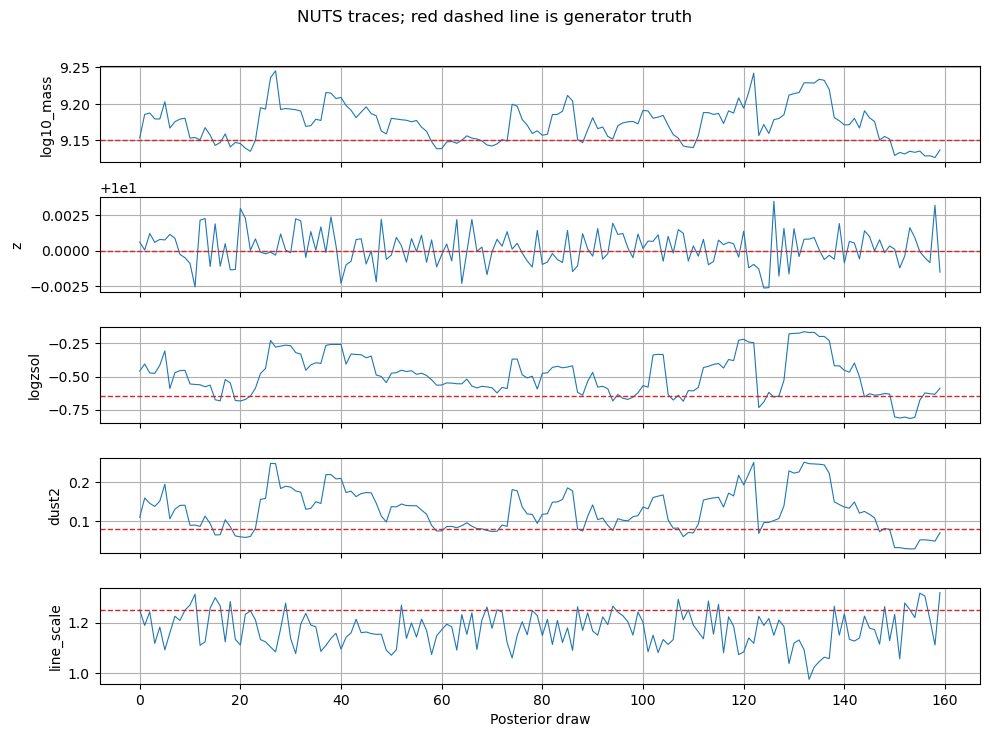

In [8]:
n_param = len(theta_names)
fig, axes = plt.subplots(n_param, 1, figsize=(10, 1.45 * n_param), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(samples[:, i], lw=0.8)
    ax.axhline(truth[i], color="tab:red", ls="--", lw=1)
    ax.set_ylabel(theta_names[i])
axes[-1].set_xlabel("Posterior draw")
fig.suptitle("NUTS traces; red dashed line is generator truth", y=1.01)
fig.tight_layout()

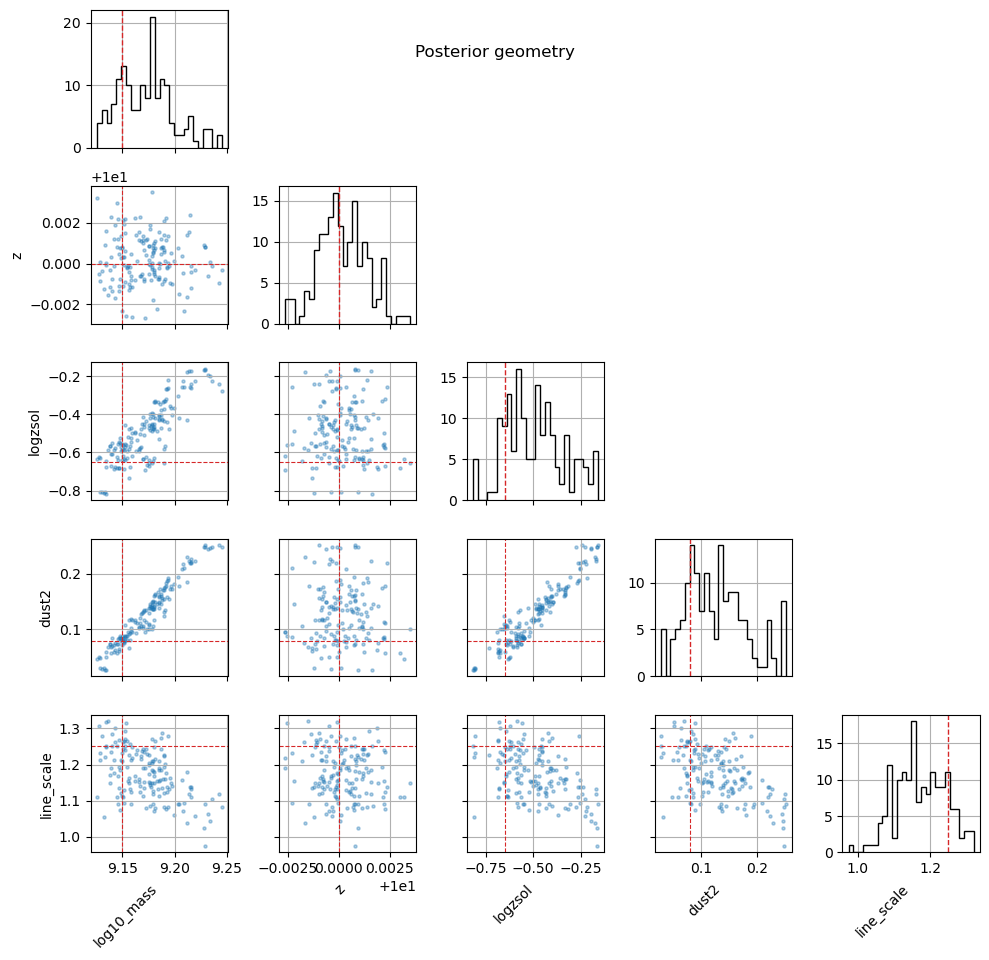

In [9]:
fig, axes = plt.subplots(n_param, n_param, figsize=(2.0 * n_param, 2.0 * n_param))
for i in range(n_param):
    for j in range(n_param):
        ax = axes[i, j]
        if i == j:
            ax.hist(samples[:, i], bins=26, histtype="step", color="black")
            ax.axvline(truth[i], color="tab:red", ls="--", lw=1)
        elif i > j:
            ax.scatter(samples[:, j], samples[:, i], s=5, alpha=0.35)
            ax.axvline(truth[j], color="tab:red", ls="--", lw=0.8)
            ax.axhline(truth[i], color="tab:red", ls="--", lw=0.8)
        else:
            ax.axis("off")
        if i == n_param - 1 and j <= i:
            ax.set_xlabel(theta_names[j], rotation=45, ha="right")
        else:
            ax.set_xticklabels([])
        if j == 0 and i > 0:
            ax.set_ylabel(theta_names[i])
        elif i != j:
            ax.set_yticklabels([])
fig.suptitle("Posterior geometry", y=0.92)
fig.tight_layout()

## Posterior predictive spectrum

Every posterior model below is passed through the same wavelength-dependent PRISM LSF and pixel binning before comparison. This is the object we would inspect for real JADES data.

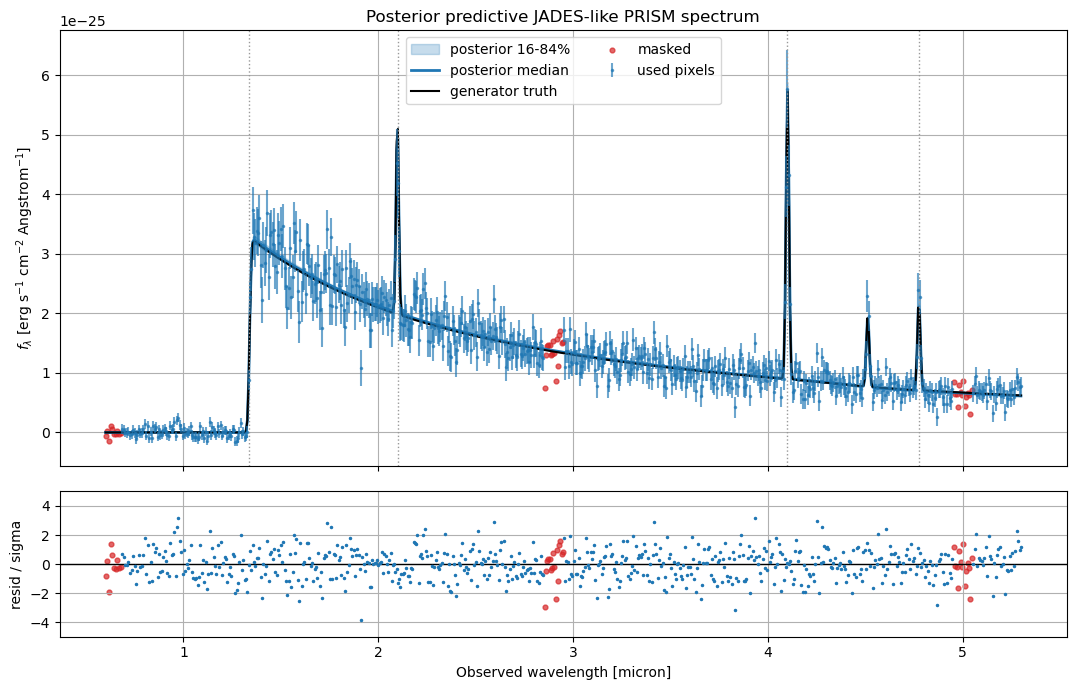

In [10]:
def pixel_model_for_theta(theta):
    state = model.run_modules_mass_scaled(jnp.asarray(theta))
    return np.asarray(
        model_spectrum_on_observed_pixels(
            state.wave_obs_a,
            state.flux_lambda_cgs,
            jnp.asarray(spectral_wave_a),
            jnp.asarray(spectral_edges_a),
            resample_mode="bin",
            resolving_power=resolving_power,
        )
    )

posterior_subset = samples[np.linspace(0, samples.shape[0] - 1, min(80, samples.shape[0]), dtype=int)]
pred = np.asarray([pixel_model_for_theta(theta) for theta in posterior_subset])
pred_q16, pred_q50, pred_q84 = np.percentile(pred, [16, 50, 84], axis=0)
truth_pixel = pixel_model_for_theta(truth)
residual_sigma = (observed_flux - pred_q50) / sigma_flux

fig, (ax, rx) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
wave_um = spectral_wave_a / 1e4
ax.fill_between(wave_um, pred_q16, pred_q84, color="tab:blue", alpha=0.25, label="posterior 16-84%")
ax.plot(wave_um, pred_q50, color="tab:blue", lw=2, label="posterior median")
ax.plot(wave_um, truth_pixel, color="black", lw=1.5, label="generator truth")
ax.errorbar(wave_um[mask], observed_flux[mask], yerr=sigma_flux[mask], fmt=".", ms=3, alpha=0.65, label="used pixels")
ax.scatter(wave_um[~mask], observed_flux[~mask], s=12, color="tab:red", alpha=0.7, label="masked")
for x in [lya_obs_um, 1908.7 * 11.0 / 1e4, oii_obs_um, hgamma_obs_um]:
    ax.axvline(x, color="0.6", ls=":", lw=1)
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Angstrom$^{-1}$]")
ax.set_title("Posterior predictive JADES-like PRISM spectrum")
ax.legend(loc="best", ncol=2)

rx.axhline(0.0, color="black", lw=1)
rx.plot(wave_um[mask], residual_sigma[mask], ".", ms=3)
rx.scatter(wave_um[~mask], residual_sigma[~mask], s=12, color="tab:red", alpha=0.7)
rx.set_xlabel("Observed wavelength [micron]")
rx.set_ylabel("resid / sigma")
rx.set_ylim(-5, 5)
fig.tight_layout()

In [11]:
active_residual = residual_sigma[mask]
metrics = {
    "n_pixels": int(mask.size),
    "n_active_pixels": int(mask.sum()),
    "median_abs_residual_sigma": float(np.median(np.abs(active_residual))),
    "rms_residual_sigma": float(np.sqrt(np.mean(active_residual**2))),
    "max_abs_residual_sigma": float(np.max(np.abs(active_residual))),
    "runtime_seconds": runtime,
}
metrics

{'n_pixels': 712,
 'n_active_pixels': 672,
 'median_abs_residual_sigma': 0.6877079782417822,
 'rms_residual_sigma': 1.0338191078062064,
 'max_abs_residual_sigma': 3.8465278754231593,
 'runtime_seconds': 29.842276874929667}

## Audit notes and next steps

Data entering the likelihood:

- observed wavelength pixels from 0.6-5.3 micron;
- observed `f_lambda` and one-sigma uncertainty in cgs per Angstrom;
- an explicit mask;
- a wavelength-dependent resolving-power array.

Transformations before residuals:

1. rest-frame spectrum is generated on a fixed rest wavelength grid;
2. dust and IGM act in rest frame;
3. redshifting and luminosity distance convert to observed `f_lambda`;
4. `10**log10_mass` is applied once;
5. model is broadened with the PRISM R(lambda) curve;
6. model is binned into observed pixels;
7. Gaussian residuals use only unmasked pixels.

Important limitations:

- The R(lambda) curve here is an approximation, not the exact STScI FITS curve.
- The source model is a toy high-z line spectrum; the next version should use DSPS + Cue.
- No slit-loss or spectrophotometric calibration nuisance polynomial is included yet.
- Real JADES spectra need data provenance, covariance/masking, and photometry-spectrum scaling.